# B4222 Project Source Code - Twitters Feature Engineering

In [2]:
# connect google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import Libraries

In [1]:
!pip install emoji
!pip install transformers

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   --------------------------------------- 608.4/608.4 kB 21.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\ADMIN\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
   ---------------------------------------- 0.0/10.2 MB ? eta -:--:--
   ----------------------- ---------------- 6.0/10.2 MB 30.8 MB/s eta 0:00:01
   ---------------------------------------- 10.2/10.2 MB 27.8 MB/s eta 0:00:00
Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl (341 kB)
Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl (2.7 MB)



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\ADMIN\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
# import packages
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
import re
import emoji
import ast
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import pipeline

# Load Dataset

In [ ]:
# load dataset (adjust path as required)
df_tweets = pd.read_parquet("./datasets/df_user_tweets_final.parquet")
df = pd.read_parquet("./datasets/df_users_final.parquet")

# copy dataset
df_tweets = df_tweets.copy()
df = df.copy()

# Data Inspection

In [7]:
df_tweets.head(10)

,id,tweets
0,u1473903209324314624,[]
1,u1606799846,[]
2,u1090297084262129665,[]
3,u20012204,[]
4,u73355398,"[{'attachments': None, 'author_id': 'u73355398..."
5,u233484050,[]
6,u1426383067791466496,[]
7,u3292006950,"[{'attachments': None, 'author_id': 'u32920069..."
8,u17604915,[]
9,u141901567,[]


In [8]:
# display information of data
df_tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      20000 non-null  object
 1   tweets  20000 non-null  object
dtypes: object(2)
memory usage: 312.6+ KB


In [9]:
# display data
df.head()

,id,label,split,participation_degree,created_at,description,location,name,pinned_tweet_id,profile_image_url,...,entities.description.urls,public_metrics.followers_count,public_metrics.following_count,public_metrics.tweet_count,public_metrics.listed_count,entities,entities.description.mentions,entities.description.hashtags,entities.description.cashtags,withheld.country_codes
0,u1217628182611927040,human,test,1893,2020-01-16 02:02:55+00:00,Theoretical Computer Scientist. See also https...,"Cambridge, MA",Boaz Barak,NaN,https://pbs.twimg.com/profile_images/125226236...,...,"[{'display_url': 'windowsontheory.org', 'end':...",7316,215,3098,69,NaN,None,None,None,None
1,u1679822588,bot,train,1127,2013-08-18 04:21:48+00:00,,🇬🇧,Grian,1.143808e+18,https://pbs.twimg.com/profile_images/100773461...,...,None,238254,293,1400,448,NaN,None,None,None,None
2,u1341789703633178624,bot,test,159,2020-12-23 16:56:30+00:00,,None,mo,NaN,https://abs.twimg.com/sticky/default_profile_i...,...,None,0,136,6,0,NaN,None,None,None,None
3,u2465283662,bot,test,3346,2014-04-27 00:20:12+00:00,"paper tweets, dms are open",None,AK,NaN,https://pbs.twimg.com/profile_images/145119163...,...,None,45541,1206,9194,605,NaN,None,None,None,None
4,u1099603759259238400,human,test,326,2019-02-24 09:35:40+00:00,,None,Ryuu09,NaN,https://pbs.twimg.com/profile_images/121992857...,...,None,8,289,0,0,NaN,None,None,None,None


In [10]:
# display information of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20000 non-null  object 
 1   label                           20000 non-null  object 
 2   split                           20000 non-null  object 
 3   participation_degree            20000 non-null  int64  
 4   created_at                      20000 non-null  object 
 5   description                     20000 non-null  object 
 6   location                        14618 non-null  object 
 7   name                            20000 non-null  object 
 8   pinned_tweet_id                 9800 non-null   float64
 9   profile_image_url               20000 non-null  object 
 10  protected                       20000 non-null  bool   
 11  url                             20000 non-null  object 
 12  username                        

## Tweets Inspection

In [11]:
# count number of users with no tweets and number of users with tweets
no_tweets_count = df_tweets['tweets'].apply(lambda x: len(x) == 0).sum()
tweets_count = df_tweets['tweets'].apply(lambda x: len(x) > 0).sum()

print("Users with no tweets: ", no_tweets_count)
print("Users with tweets: ", tweets_count)

Users with no tweets:  15142
Users with tweets:  4858


In [12]:
# descriptive statistics of tweets (for all users)
df_tweets_copy = df_tweets.copy()
df_tweets_copy['num_tweets'] = df_tweets_copy['tweets'].apply(lambda x: len(x))
df_tweets_copy['num_tweets'].describe()

,num_tweets
count,20000.000000
mean,7.759850
std,52.238056
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1526.000000


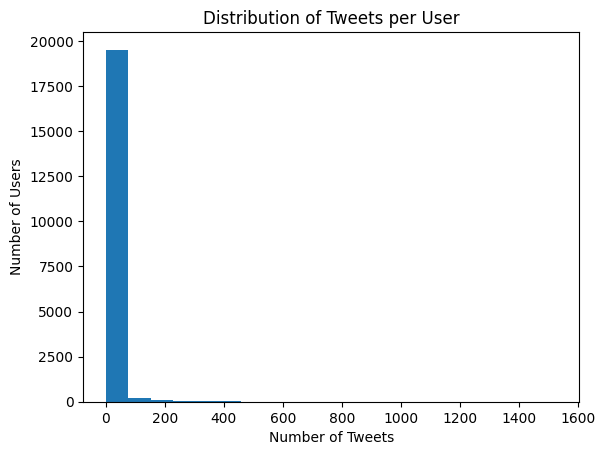

In [13]:
# histogram of tweets per user (for all users)
plt.figure()
plt.hist(df_tweets_copy['num_tweets'], bins=20)

plt.xlabel('Number of Tweets')
plt.ylabel('Number of Users')
plt.title('Distribution of Tweets per User')

plt.show()

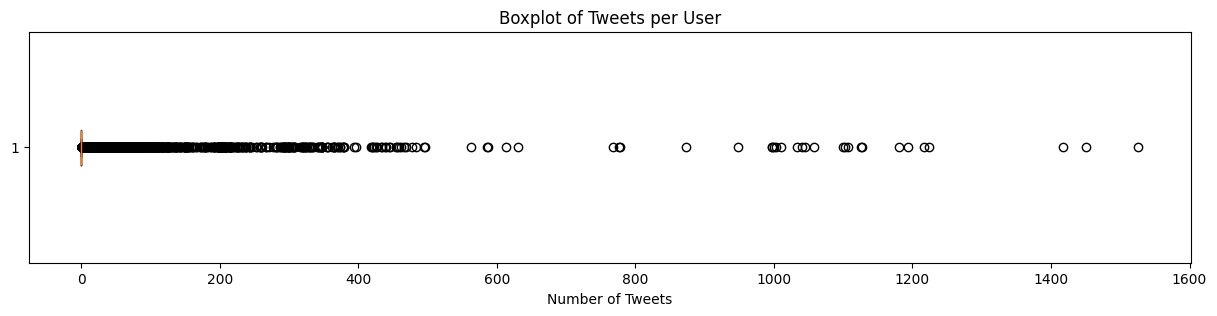

In [14]:
# boxplot of tweets per user (for all users)
plt.figure(figsize=(15, 3))
plt.boxplot(df_tweets_copy['num_tweets'], vert=False)

plt.xlabel('Number of Tweets')
plt.title('Boxplot of Tweets per User')

plt.show()

In [15]:
# descriptive statistics of tweets (for users with tweets)
df_tweets_users_with_tweets = df_tweets[df_tweets['tweets'].apply(lambda x: len(x)) > 0].copy()
df_tweets_users_with_tweets ['num_tweets'] = df_tweets_users_with_tweets ['tweets'].apply(lambda x: len(x))
df_tweets_users_with_tweets ['num_tweets'].describe()

,num_tweets
count,4858.000000
mean,31.946686
std,102.289860
min,1.000000
25%,1.000000
50%,4.000000
75%,14.000000
max,1526.000000


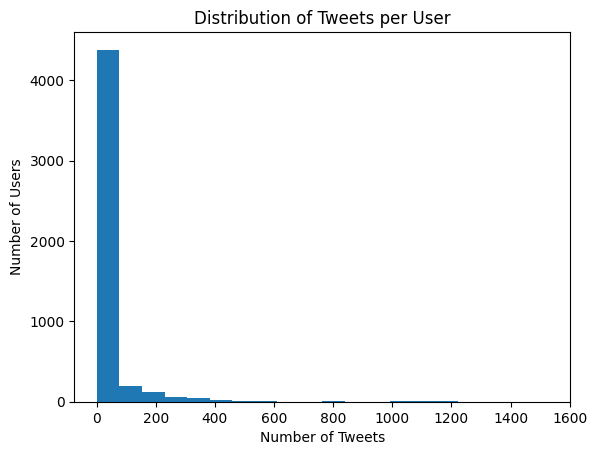

In [16]:
# histogram of tweets per user (for users with tweets)
plt.figure()
plt.hist(df_tweets_users_with_tweets ['num_tweets'], bins=20)

plt.xlabel('Number of Tweets')
plt.ylabel('Number of Users')
plt.title('Distribution of Tweets per User')

plt.show()

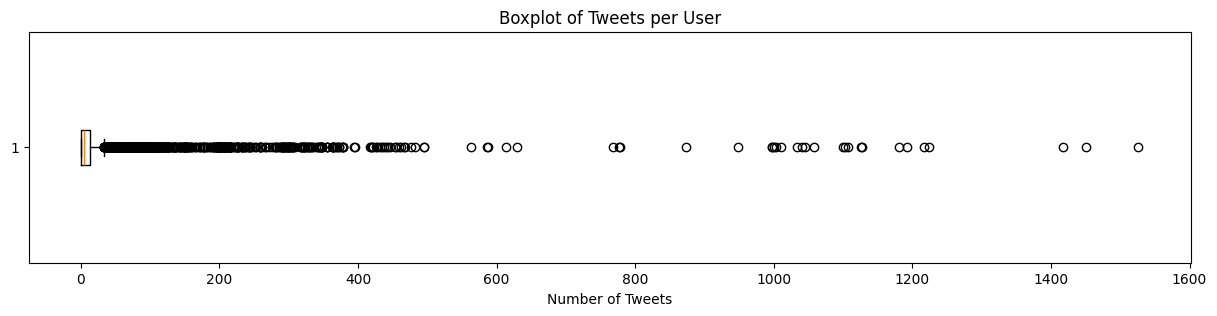

In [17]:
# boxplot of tweets per user (for users with tweets)
plt.figure(figsize=(15, 3))
plt.boxplot(df_tweets_users_with_tweets ['num_tweets'], vert=False)

plt.xlabel('Number of Tweets')
plt.title('Boxplot of Tweets per User')

plt.show()

# Feature Engineering

## User Activity Features

In [18]:
# whether or not user has tweets
df_tweets["has_tweets"] = df_tweets["tweets"].apply(lambda x: len(x) != 0).astype(int)

# number tweets
df_tweets["num_tweets"] = df_tweets["tweets"].apply(lambda x: len(x))

In [19]:
# tweet frequency -> average number of tweets per day relative to age
# lookup dictionary: user_id -> created_at
created_at_map = df.set_index('id')['created_at'].to_dict()

def compute_tweet_frequency(row):
  tweet_list = row['tweets']
  user_id = row['id']

  # number of tweets
  num_tweets = row['num_tweets']

  if num_tweets == 0:
    return 0

  # account creation date
  created_at_str = created_at_map.get(user_id)

  if created_at_str is None:
    return 0

  # parse datetime
  created_at = datetime.fromisoformat(created_at_str.replace('Z', '+00:00'))

  # current reference time
  now = datetime.now(created_at.tzinfo)

  account_age_days = (now - created_at).days

  # avoid division by 0
  if account_age_days <= 0:
    return 0

  return num_tweets / account_age_days

df_tweets['tweets_frequency'] = df_tweets.apply(compute_tweet_frequency, axis=1)

In [20]:
# posting regularity -> variance of time gaps between consecutive tweets
def compute_posting_regularity(tweet_list):
  timestamps = []

  # extract timestamps
  for t in tweet_list:
    if 'created_at' in t:
      timestamps.append(
        datetime.fromisoformat(t['created_at'].replace('Z', '+00:00'))
      )

  # edge cases
  if len(timestamps) <= 2:
    return 0  # not enough data to compute meaningful variance

  timestamps.sort()

  # compute time differences in days
  diffs = [
    (timestamps[i] - timestamps[i-1]).total_seconds() / (60*60*24)
    for i in range(1, len(timestamps))
  ]

  return np.var(diffs)

df_tweets['posting_regularity'] = df_tweets['tweets'].apply(compute_posting_regularity)

## Content Features

In [21]:
# text length
def compute_text_length(tweet_list):
  lengths = []
  word_counts = []
  word_lengths = []

  for tweet in tweet_list:
    text = tweet.get('text')

    # skip if text is None or empty
    if text is None:
      continue

    # character length
    char_len = len(text)
    lengths.append(char_len)

    # words
    words = re.findall(r'\w+', text)
    word_counts.append(len(words))

    # avg word length in this tweet
    if len(words) > 0:
      word_lengths.append(sum(len(w) for w in words) / len(words))

  # aggregate across tweets in the row
  if len(lengths) == 0:
    return pd.Series([0, 0, 0])

  avg_length = sum(lengths) / len(lengths)
  avg_words = sum(word_counts) / len(word_counts)
  avg_word_length = sum(word_lengths) / len(word_lengths)

  return pd.Series([avg_length, avg_words, avg_word_length])

df_tweets[['avg_length_per_tweet',
           'avg_words_per_tweet',
           'avg_word_length_per_tweet']] = df_tweets['tweets'].apply(compute_text_length)

In [22]:
# text style
def compute_text_style(tweet_list):
  uppercase_pct = []
  digit_pct = []
  special_char_pct = []
  emoji_count = []

  for tweet in tweet_list:
    text = tweet.get('text')

    # skip if text is None or empty
    if text is None:
      continue

    total_chars = len(text)

    uppercase_count = sum(1 for c in text if c.isupper())
    uppercase_pct.append(uppercase_count / total_chars)

    digit_count = sum(1 for c in text if c.isdigit())
    digit_pct.append(digit_count / total_chars)

    special_chars = 0
    for c in text:
        if not c.isalnum() and c not in [' ', '#', '@']:
            special_chars += 1
    special_char_pct.append(special_chars / total_chars)

    emoji_count.append(len(emoji.emoji_list(text)))

  if len(tweet_list) == 0:
      return pd.Series([0, 0, 0, 0])

  return pd.Series([
      sum(uppercase_pct) / len(uppercase_pct),
      sum(digit_pct) / len(digit_pct),
      sum(special_char_pct) / len(special_char_pct),
      sum(emoji_count) / len(emoji_count)
  ])

df_tweets[['avg_uppercase_pct',
           'avg_digit_pct',
           'avg_special_char_pct',
           'avg_emoji']] = df_tweets['tweets'].apply(compute_text_style)

In [23]:
# hashtags
def compute_hashtag(tweet_list):
  hashtags_per_tweet = []
  unique_hashtags_per_tweet = []
  has_hashtag_flags = []

  for tweet in tweet_list:
    entities = tweet.get('entities')

    if not entities:
      continue

    if isinstance(entities, str):
      try:
        entities_dict = ast.literal_eval(entities)
      except:
        continue
    else:
      entities_dict = entities

    hashtags = entities_dict.get('hashtags', [])

    hashtag_tags = []
    for h in hashtags:
      if isinstance(h, dict) and 'tag' in h:
        hashtag_tags.append(h['tag'])

    hashtags_per_tweet.append(len(hashtag_tags))
    unique_hashtags_per_tweet.append(len(set(hashtag_tags)))
    has_hashtag_flags.append(1 if len(hashtag_tags) > 0 else 0)

  if len(hashtags_per_tweet) == 0:
    return pd.Series([0, 0, 0])

  avg_hashtags = sum(hashtags_per_tweet) / len(hashtags_per_tweet)
  avg_unique_hashtags = sum(unique_hashtags_per_tweet) / len(unique_hashtags_per_tweet)
  pct_tweets_with_hashtags = sum(has_hashtag_flags) / len(has_hashtag_flags)

  overuse_hashtags = 1 if avg_unique_hashtags < avg_hashtags else 0

  return pd.Series([avg_hashtags, overuse_hashtags, pct_tweets_with_hashtags])

df_tweets[['avg_hashtags_per_tweet',
           'overuse_hashtags',
           'pct_tweets_with_hashtags']] = df_tweets['tweets'].apply(compute_hashtag)

# make overuse_hashtags binary
df_tweets['overuse_hashtags'] = df_tweets['overuse_hashtags'].astype(int)

In [24]:
# mentions
def compute_mention(tweet_list):
  mentions_per_tweet = []
  has_mentions_flags = []

  for tweet in tweet_list:
    entities = tweet.get('entities')

    if not entities:
      continue

    if isinstance(entities, str):
      try:
        entities_dict = ast.literal_eval(entities)
      except:
        continue
    else:
      entities_dict = entities

    mentions = entities_dict.get('mentions') or entities_dict.get('user_mentions') or []

    mentions_per_tweet.append(len(mentions))
    has_mentions_flags.append(1 if len(mentions) > 0 else 0)

  if len(mentions_per_tweet) == 0:
    return pd.Series([0, 0])

  avg_mentions = sum(mentions_per_tweet) / len(mentions_per_tweet)
  pct_tweets_with_mentions = sum(has_mentions_flags) / len(has_mentions_flags)

  return pd.Series([avg_mentions, pct_tweets_with_mentions])

df_tweets[['avg_mentions_per_tweet',
           'pct_tweets_with_mentions']] = df_tweets['tweets'].apply(compute_mention)

In [25]:
# urls
def compute_url(tweet_list):
  urls_per_tweet = []
  has_urls_flags = []

  for tweet in tweet_list:
    entities = tweet.get('entities')

    if not entities:
      continue

    if isinstance(entities, str):
      try:
        entities_dict = ast.literal_eval(entities)
      except:
        continue
    else:
      entities_dict = entities

    urls = entities_dict.get('urls', [])

    urls_per_tweet.append(len(urls))
    has_urls_flags.append(1 if len(urls) > 0 else 0)

  if len(urls_per_tweet) == 0:
    return pd.Series([0, 0])

  avg_urls = sum(urls_per_tweet) / len(urls_per_tweet)
  pct_tweets_with_urls = sum(has_urls_flags) / len(has_urls_flags)

  return pd.Series([avg_urls, pct_tweets_with_urls])

df_tweets[['avg_urls_per_tweet',
           'pct_tweets_with_urls']] = df_tweets['tweets'].apply(compute_url)

In [26]:
# media/attachment
def compute_attachment(tweet_list):
  attachments_per_tweet = []
  has_attachments_flags = []

  for tweet in tweet_list:
    attachments = tweet.get('attachments', [])

    if not attachments:
      continue

    attachments_per_tweet.append(len(attachments))
    has_attachments_flags.append(1 if len(attachments) > 0 else 0)

  if len(attachments_per_tweet) == 0:
    return pd.Series([0, 0])

  avg_attachments = sum(attachments_per_tweet) / len(attachments_per_tweet)
  pct_tweets_with_attachments = sum(has_attachments_flags) / len(has_attachments_flags)

  return pd.Series([avg_attachments, pct_tweets_with_attachments])

df_tweets[['avg_attachments_per_tweet',
           'pct_tweets_with_attachments']] = df_tweets['tweets'].apply(compute_attachment)

In [27]:
# sensitivity
def compute_sensitivity(tweet_list):
  sensitivity_per_tweet = []

  for tweet in tweet_list:
    sensitivity = tweet.get('possibly_sensitive', False)
    sensitivity_per_tweet.append(1 if sensitivity else 0)

  if len(sensitivity_per_tweet) == 0:
    return 0
  else:
    return sum(sensitivity_per_tweet) / len(sensitivity_per_tweet)

df_tweets["avg_sensitive"] = df_tweets['tweets'].apply(compute_sensitivity)

### Sentiment Analysis

In [ ]:
# setup model
model_name = "cardiffnlp/twitter-roberta-base-sentiment"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=0 # use GPU
)

# flatten tweets
all_texts = []
tweet_counts = []  # to map back later

for tweet_list in df_tweets['tweets']:
  texts = [t.get('text') for t in tweet_list if t.get('text')]

  texts = [t[:128] for t in texts] # truncate for speed

  all_texts.extend(texts)
  tweet_counts.append(len(texts))

# run batched sentiment
results = sentiment_pipeline(
    all_texts,
    batch_size=32,
    truncation=True
)

# map labels
mapped_sentiments = []

for r in results:
  label = r['label']
  if label == "LABEL_2":
    mapped_sentiments.append("positive")
  elif label == "LABEL_0":
    mapped_sentiments.append("negative")
  else:
    mapped_sentiments.append("neutral")

# reconstruct rows
idx = 0
features = []
for count in tweet_counts:
  if count == 0:
    features.append([0, 0, 0])
    continue

  subset = mapped_sentiments[idx : idx + count]
  idx += count

  total = len(subset)

  pos = subset.count("positive") / total
  neg = subset.count("negative") / total
  neu = subset.count("neutral") / total

  features.append([pos, neg, neu])

df_tweets[['avg_positive', 'avg_negative', 'avg_neutral']] = pd.DataFrame(features)

## Interaction Features

In [29]:
# type of tweets
def compute_tweet_types(tweet_list):
  retweets = 0
  quotes = 0
  replies = 0
  originals = 0

  for tweet in tweet_list:
    ref = tweet.get("referenced_tweets")
    ref_types = []

    # parse referenced_tweets if needed
    if ref is not None:
      if isinstance(ref, str):
        try:
          ref = ast.literal_eval(ref)
        except:
          ref = None

      if isinstance(ref, list):
        ref_types = [r.get("type") for r in ref if isinstance(r, dict)]

    reply_flag = tweet.get("in_reply_to_user_id") is not None

    is_reply = reply_flag or ("replied_to" in ref_types)
    is_retweet = "retweeted" in ref_types
    is_quote = "quoted" in ref_types

    # classify
    if is_reply:
      replies += 1
    if is_retweet:
      retweets += 1
    if is_quote:
      quotes += 1
    if not (is_reply or is_retweet or is_quote):
      originals += 1

  num_tweets = len(tweet_list)

  if num_tweets == 0:
    return pd.Series([0, 0, 0, 0])
  else:
    return pd.Series([
        retweets / num_tweets,
        quotes / num_tweets,
        replies / num_tweets,
        originals / num_tweets
    ])

df_tweets[["avg_retweets", "avg_quotes", "avg_replies", "avg_originals"]] = (
  df_tweets["tweets"].apply(lambda x: pd.Series(compute_tweet_types(x)))
)

## Engagement Features

In [30]:
def compute_engagement(tweet_list):
  retweets_per_tweet = []
  replies_per_tweet = []
  likes_per_tweet = []
  quotes_per_tweet = []
  engagement_rate_per_tweet = []

  for tweet in tweet_list:
    metrics = tweet.get('public_metrics')

    if not metrics:
      continue

    if isinstance(metrics, str):
      try:
        metrics_dict = ast.literal_eval(metrics)
      except:
        continue
    else:
      metrics_dict = metrics

    retweets_per_tweet.append(metrics_dict.get('retweet_count') or 0)
    replies_per_tweet.append(metrics_dict.get('reply_count') or 0)
    likes_per_tweet.append(metrics_dict.get('like_count') or 0)
    quotes_per_tweet.append(metrics_dict.get('quote_count') or 0)

  if len(tweet_list) == 0:
    return pd.Series([0, 0, 0, 0, 0])

  avg_likes = sum(likes_per_tweet) / len(likes_per_tweet)
  avg_retweets = sum(retweets_per_tweet) / len(retweets_per_tweet)
  avg_replies = sum(replies_per_tweet) / len(replies_per_tweet)
  avg_quotes = sum(quotes_per_tweet) / len(quotes_per_tweet)

  engagement_rate = (
      sum(likes_per_tweet) +
      sum(retweets_per_tweet) +
      sum(replies_per_tweet) +
      sum(quotes_per_tweet)
  ) / len(tweet_list)

  return pd.Series([avg_likes, avg_retweets, avg_replies, avg_quotes, engagement_rate])

df_tweets[['avg_likes_per_tweet',
           'avg_retweets_per_tweet',
           'avg_replies_per_tweet',
           'avg_quotes_per_tweet',
           'engagement_rate']] = df_tweets['tweets'].apply(compute_engagement)

In [31]:
# reply settings
def compute_reply_settings(tweet_list):
  reply_settings_flags = []

  for tweet in tweet_list:
    reply_settings = tweet.get('reply_settings')

    reply_settings_flags.append(1 if reply_settings is not None else 0)

  if len(reply_settings_flags) == 0:
    return 0

  pct_reply_settings = sum(reply_settings_flags) / len(reply_settings_flags)

  return pct_reply_settings

df_tweets['pct_allow_reply'] = df_tweets['tweets'].apply(compute_reply_settings)

In [32]:
# feature crossing between reply settings and number of replies
def compute_fc_reply(tweet_list):
  total_replies = 0
  count_allow_reply = 0

  if len(tweet_list) == 0:
      return 0

  for tweet in tweet_list:
    # reply settings
    reply_settings = tweet.get('reply_settings')
    reply_settings_flag = 1 if reply_settings is not None else 0

    # replies
    metrics = tweet.get('public_metrics')

    if not metrics:
      continue

    if isinstance(metrics, str):
      try:
        metrics_dict = ast.literal_eval(metrics)
      except:
        continue
    else:
      metrics_dict = metrics

    reply_count = metrics_dict.get('reply_count') or 0

    total_replies += reply_count
    count_allow_reply += reply_settings_flag

  if count_allow_reply == 0:
    return 0
  else:
    return total_replies / count_allow_reply

df_tweets['fc_reply'] = df_tweets['tweets'].apply(compute_fc_reply)

## Other Features

In [33]:
# language
def compute_language(tweet_list):
    langs = []

    for tweet in tweet_list:
        lang = tweet.get('lang')

        if not lang:
            continue

        langs.append(lang)

    if len(langs) == 0:
        return 0

    num_unique_langs = len(set(langs))

    return num_unique_langs

df_tweets['num_unique_langs'] = df_tweets['tweets'].apply(compute_language)

In [34]:
# geo-enabled
def compute_geo(tweet_list):
    geo_flags = []

    for tweet in tweet_list:
        geo = tweet.get('geo')

        geo_flags.append(1 if geo is not None else 0)

    if len(geo_flags) == 0:
        return 0

    pct_geo = sum(geo_flags) / len(geo_flags)

    return pct_geo

df_tweets['pct_geo_tweets'] = df_tweets['tweets'].apply(compute_geo)

## Suspicious Behaviour

In [35]:
def count_inconsistencies(tweet_list):
  has_inconsistencies = 0
  count = 0

  for tweet in tweet_list:
    ref = tweet.get("referenced_tweets")
    ref_is_none = ref is None

    ref_types = []

    if ref is not None:
      if isinstance(ref, str):
        try:
          ref = ast.literal_eval(ref)
        except:
          ref = None

      if isinstance(ref, list):
        ref_types = [r.get("type") for r in ref if isinstance(r, dict)]

    reply_flag = tweet.get("in_reply_to_user_id") is not None
    is_reply_ref = "replied_to" in ref_types

    # inconsistency condition
    if (reply_flag and ref_is_none) or (not reply_flag and is_reply_ref):
      count += 1

  if (count != 0):
      has_inconsistencies = 1

  return pd.Series([has_inconsistencies, count])

df_tweets[["has_reply_inconsistency", "reply_inconsistency_count"]] = df_tweets["tweets"].apply(count_inconsistencies)

# Summary

Total number of features: 39 \
Number of numerical features: 36 \
Number of binary features: 3 -> `has_tweets`, `overuse_hashtags`, `has_reply_inconsistency`
*   User Activity
    *   whether or not user has tweets `has_tweets`
    *   total number of tweets `num_tweets`
    *   tweet frequency -> average number of tweets per day relative to age `tweet_frequency`
    *   posting regularity -> variance of time gaps between consecutive tweets (in days) `posting_regularity`
*   Content Features
    *   Text Length
        *   average length per tweet `avg_length_per_tweet`
        *   average number of words per tweet `avg_words_per_tweet`
        *   average word length per tweet `avg_word_length_per_tweet`
        *   NOTE: values are inaccurate as the text of each tweet is truncated
    *   Text Style
        *   average percentage of uppercase characters in a tweet `avg_uppercase_pct`
        *   average percentage of digits in a tweet `avg_digit_pct`
        *   average percentage of special characters in a tweet (excluding # and @) `avg_special_char_pct`
        *   average number of emojis per tweet `avg_emoji`
        *   NOTE: values are inaccurate as the text of each tweet is truncated
    *   Hashtags
        *   average number of hashtags per tweet `avg_hashtags_per_tweet`
        *   whether or not the same hashtag is used twice in a tweet `overuse_hashtags`
        *   percentage of tweets with hashtags `pct_tweets_with_hashtags`
    *   Mentions
        *   average number of mentions per tweet `avg_mentions_per_tweet`
        *   percentage of tweets with mentions `pct_tweets_with_mentions`
    *   URLs
        *   average number of URLs per tweet `avg_urls_per_tweet`
        *   percentage of tweets with URLs `pct_tweets_with_urls`
    *   Attachments
        *   average number of attachments per tweet `avg_attachments_per_tweet`
        *   percentage of tweets with attachments `pct_tweets_with_attachments`
    *   Sensitivity of tweet
        *   average number of sensitive tweets `avg_sensitive`
    *   Sentiment Analysis
        *   average number of positive tweets `avg_positive`
        *   average number of negative tweets `avg_negative`
        *   average number of neutral tweets `avg_neutral`
        *   NOTE: values are inaccurate as the text of each tweet is truncated
*   Interaction Features
    *   average number of retweets `avg_retweets`
    *   average number of quoted tweets `avg_quotes`
    *   average number of tweets that are replies to other users `avg_replies`
    *   average number of original tweets `avg_originals`
*   Engagement Features
    *   average number of likes per tweet `avg_likes_per_tweet`
    *   average number of retweets per tweet `avg_retweets_per_tweet`
    *   average number of replies per tweet `avg_replies_per_tweet`
    *   average number of quotes per tweet `avg_quotes_per_tweet`
    *   engagement rate `engagement_rate`
    *   percentage of tweets with reply settings enabled `pct_allow_reply`
    *   feature crossing between reply settings and number of replies `fc_reply`
*   Other Features
    *   total number of languages used `num_unique_langs`
    *   percentage of geo-enabled tweets `pct_geo_tweets`   
*   Suspicious behaviour
    *   whether or not user has reply inconsistencies `has_reply_inconsistency`
    *   number of reply inconsistencies -> count of inconsistent behaviour between in_reply_to_user_id and type of referenced_tweets `reply_inconsistency_count`



In [36]:
# display data with new features
df_tweets.head()

,id,tweets,has_tweets,num_tweets,tweets_frequency,posting_regularity,avg_length_per_tweet,avg_words_per_tweet,avg_word_length_per_tweet,avg_uppercase_pct,...,avg_retweets_per_tweet,avg_replies_per_tweet,avg_quotes_per_tweet,engagement_rate,pct_allow_reply,fc_reply,num_unique_langs,pct_geo_tweets,has_reply_inconsistency,reply_inconsistency_count
0,u1473903209324314624,[],0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0,0.0,0,0
1,u1606799846,[],0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0,0.0,0,0
2,u1090297084262129665,[],0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0,0.0,0,0
3,u20012204,[],0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0,0.0,0,0
4,u73355398,"[{'attachments': None, 'author_id': 'u73355398...",1,26,0.004294,636.323542,127.730769,21.307692,4.762956,0.068616,...,8.653846,0.615385,0.346154,22.884615,1.0,0.615385,2,0.0,0,0


In [37]:
# display types of features
df_tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           20000 non-null  object 
 1   tweets                       20000 non-null  object 
 2   has_tweets                   20000 non-null  int64  
 3   num_tweets                   20000 non-null  int64  
 4   tweets_frequency             20000 non-null  float64
 5   posting_regularity           20000 non-null  float64
 6   avg_length_per_tweet         20000 non-null  float64
 7   avg_words_per_tweet          20000 non-null  float64
 8   avg_word_length_per_tweet    20000 non-null  float64
 9   avg_uppercase_pct            20000 non-null  float64
 10  avg_digit_pct                20000 non-null  float64
 11  avg_special_char_pct         20000 non-null  float64
 12  avg_emoji                    20000 non-null  float64
 13  avg_hashtags_per

In [38]:
# display descriptive statistics of numeric features
non_numeric_cols = ['id', 'tweets', 'has_tweets', 'overuse_hashtags', 'has_reply_inconsistency']
numeric_cols = df_tweets.columns.difference(non_numeric_cols)

df_tweets[numeric_cols].describe()

,avg_attachments_per_tweet,avg_digit_pct,avg_emoji,avg_hashtags_per_tweet,avg_length_per_tweet,avg_likes_per_tweet,avg_mentions_per_tweet,avg_negative,avg_neutral,avg_originals,...,num_unique_langs,pct_allow_reply,pct_geo_tweets,pct_tweets_with_attachments,pct_tweets_with_hashtags,pct_tweets_with_mentions,pct_tweets_with_urls,posting_regularity,reply_inconsistency_count,tweets_frequency
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000
mean,3.455513,0.004304,0.093875,0.056150,38.267158,1.167415e+03,0.458523,0.030517,0.137641,0.120404,...,0.405150,0.123836,0.001666,0.076650,0.026505,0.169433,0.093181,4.945432e+03,1.262650,0.002163
std,12.441205,0.011994,0.508269,0.382552,76.669360,2.139834e+04,1.646469,0.130096,0.298077,0.304565,...,1.080167,0.319422,0.028088,0.266042,0.124014,0.356850,0.248144,5.863536e+04,11.967202,0.014920
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
max,116.000000,0.227918,20.000000,21.230769,893.000000,1.528519e+06,49.500000,1.000000,1.000000,1.000000,...,28.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.068623e+06,423.000000,0.804661


In [39]:
# display information of binary features
print("has_tweets counts:")
print(df_tweets['has_tweets'].value_counts())

print("\noveruse_hashtags counts:")
print(df_tweets['overuse_hashtags'].value_counts())

print("\nhas_reply_inconsistency counts:")
print(df_tweets['has_reply_inconsistency'].value_counts())

has_tweets counts:
has_tweets
0    15142
1     4858
Name: count, dtype: int64

overuse_hashtags counts:
overuse_hashtags
0    19913
1       87
Name: count, dtype: int64

has_reply_inconsistency counts:
has_reply_inconsistency
0    18752
1     1248
Name: count, dtype: int64


# Export Features

In [40]:
!pip install pyarrow

In [41]:
df_tweets.to_parquet("df_tweets_model.parquet", index=False)

from google.colab import files
files.download("df_tweets_model.parquet")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>